In [2]:
!pip install transformers datasets torch scikit-learn pandas hazm matplotlib seaborn

  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 887.2/887.2 kB 23.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 81.3 MB/s eta 0:00:00
  Created wheel for flashtext: filename=flashtext-2.7-py2.py3-none-any.whl size=9300 sha256=728d2608ccb2544037d13f62cdba107291e7d890ec82029c9682cc59c2ea824c
  Stored in directory: /root/.cache/pip/wheels/8c/24/da/4d994d7a27cfc73a4e513a669fbeec4a71f871fe245a81977f
Successfully built flashtext


In [3]:
import os
import torch
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from hazm import Normalizer
from sklearn.metrics import accuracy_score, precision_recall_fscore_support, confusion_matrix
from sklearn.preprocessing import LabelEncoder
from transformers import AutoTokenizer, AutoModelForSequenceClassification, Trainer, TrainingArguments
from datasets import Dataset

In [4]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [5]:
train_df = pd.read_csv('/content/drive/MyDrive/final_project/train.tsv', sep='\t', names=['text', 'label'], header=None)
test_df = pd.read_csv('/content/drive/MyDrive/final_project/test.tsv', sep='\t', names=['text', 'label'], header=None)

In [6]:
print(train_df.shape)
print(train_df['label'].value_counts())

(6125, 2)
label
OTHER       1681
ANGRY        923
SAD          896
FEAR         757
SURPRISE     739
HAPPY        618
HATE         511
Name: count, dtype: int64


In [7]:
device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Using device: {device}")
if device == "cuda":
    print(f"GPU Name: {torch.cuda.get_device_name(0)}")

MODEL_NAME = "HooshvareLab/bert-base-parsbert-uncased"

Using device: cuda
GPU Name: Tesla T4


In [8]:
from sklearn.model_selection import train_test_split

train_df, val_df = train_test_split(
    train_df,
    test_size=0.1,
    stratify=train_df['label'],
    random_state=42
)

print("Train:", train_df.shape)
print("Validation:", val_df.shape)
print("Test:", test_df.shape)

Train: (5512, 2)
Validation: (613, 2)
Test: (1151, 2)


In [9]:
import re
from hazm import Normalizer
from sklearn.preprocessing import LabelEncoder

normalizer = Normalizer()

def preprocess_text(text):
    if not isinstance(text, str):
        return ""
    text = re.sub(r"https?://\S+|www\.\S+|@\w+", " ", text)
    text = normalizer.normalize(text)
    text = re.sub(r"\s+", " ", text).strip()
    return text

for df in [train_df, val_df, test_df]:
    df['clean_text'] = df['text'].apply(preprocess_text)

label_encoder = LabelEncoder()
train_df['label_encoded'] = label_encoder.fit_transform(train_df['label'])
val_df['label_encoded']   = label_encoder.transform(val_df['label'])
test_df['label_encoded']  = label_encoder.transform(test_df['label'])

class_names = list(label_encoder.classes_)
num_labels = len(class_names)
print(f"Detected {num_labels} emotion classes: {class_names}")

Detected 7 emotion classes: ['ANGRY', 'FEAR', 'HAPPY', 'HATE', 'OTHER', 'SAD', 'SURPRISE']


In [10]:
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

def tokenize_function(examples):
    return tokenizer(examples['clean_text'], padding="max_length", truncation=True, max_length=128)

train_dataset = Dataset.from_pandas(train_df[['clean_text', 'label_encoded']].rename(columns={'label_encoded': 'label'}))
val_dataset   = Dataset.from_pandas(val_df[['clean_text', 'label_encoded']].rename(columns={'label_encoded': 'label'}))
test_dataset  = Dataset.from_pandas(test_df[['clean_text', 'label_encoded']].rename(columns={'label_encoded': 'label'}))

train_dataset = train_dataset.map(tokenize_function, batched=True)
val_dataset   = val_dataset.map(tokenize_function, batched=True)
test_dataset  = test_dataset.map(tokenize_function, batched=True)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:112: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/434 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/1.22M [00:00<?, ?B/s]

Map:   0%|          | 0/5512 [00:00<?, ? examples/s]

Map:   0%|          | 0/613 [00:00<?, ? examples/s]

Map:   0%|          | 0/1151 [00:00<?, ? examples/s]

In [11]:
def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=1)
    acc = accuracy_score(labels, preds)
    precision, recall, f1, _ = precision_recall_fscore_support(labels, preds, average='macro')
    return {
        'accuracy': acc,
        'f1_macro': f1,
        'precision_macro': precision,
        'recall_macro': recall
    }

In [12]:
import torch.nn as nn
from sklearn.utils.class_weight import compute_class_weight

class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(train_df['label_encoded']),
    y=train_df['label_encoded']
)
class_weights = torch.tensor(class_weights, dtype=torch.float).to(device)
print("Class weights:", dict(zip(class_names, class_weights.tolist())))

Class weights: {'ANGRY': 0.9475674629211426, 'FEAR': 1.1562827825546265, 'HAPPY': 1.4162384271621704, 'HATE': 1.711801290512085, 'OTHER': 0.5204418897628784, 'SAD': 0.9769585132598877, 'SURPRISE': 1.1841031312942505}


In [13]:
class WeightedTrainer(Trainer):
    def compute_loss(self, model, inputs, return_outputs=False, **kwargs):
        labels = inputs.pop("labels")
        outputs = model(**inputs)
        loss = nn.functional.cross_entropy(outputs.logits, labels, weight=class_weights)
        return (loss, outputs) if return_outputs else loss

In [14]:
from transformers import EarlyStoppingCallback

model = AutoModelForSequenceClassification.from_pretrained(MODEL_NAME, num_labels=num_labels)

training_args = TrainingArguments(
    output_dir="./results",
    learning_rate=2e-5,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=32,
    num_train_epochs=8,
    weight_decay=0.01,
    eval_strategy="epoch",
    save_strategy="epoch",
    load_best_model_at_end=True,
    metric_for_best_model="f1_macro",
    logging_steps=50,
    report_to="none"
)

trainer = WeightedTrainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=val_dataset,
    compute_metrics=compute_metrics,
    callbacks=[EarlyStoppingCallback(early_stopping_patience=2)],
)

pytorch_model.bin:   0%|          | 0.00/654M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] BertForSequenceClassification LOAD REPORT from: HooshvareLab/bert-base-parsbert-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.decoder.bias               | UNEXPECTED | 
cls.predictions.decoder.weight             | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
classifier.weight                          | MISSING    | 
classifier.bias                            | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING

model.safetensors:   0%|          | 0.00/654M [00:00<?, ?B/s]

In [15]:
print("\n--- Starting ParsBERT Training ---")
trainer.train()


--- Starting ParsBERT Training ---


Epoch,Training Loss,Validation Loss,Accuracy,F1 Macro,Precision Macro,Recall Macro
1,0.958313,0.919918,0.639478,0.654050,0.648538,0.674163
2,0.600202,0.938817,0.672104,0.686242,0.674975,0.710957
3,0.346269,1.031213,0.652529,0.673665,0.666752,0.700328
4,0.187761,1.256908,0.690049,0.699226,0.697695,0.704607
5,0.117241,1.432289,0.686786,0.699866,0.694151,0.709786
6,0.028902,1.550233,0.681892,0.694274,0.686287,0.706162
7,0.049197,1.693065,0.686786,0.697402,0.693041,0.705744


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

TrainOutput(global_step=2415, training_loss=0.3639482853452118, metrics={'train_runtime': 981.8911, 'train_samples_per_second': 44.909, 'train_steps_per_second': 2.811, 'total_flos': 2538083177011200.0, 'train_loss': 0.3639482853452118, 'epoch': 7.0})

In [16]:
print("\n--- Final Evaluation on Held-Out TEST Set ---")
test_results = trainer.evaluate(eval_dataset=test_dataset)
print(f"Final Test Accuracy: {test_results['eval_accuracy']:.4f}")
print(f"Final Test Macro F1-Score: {test_results['eval_f1_macro']:.4f}")


--- Final Evaluation on Held-Out TEST Set ---


Training Loss,Validation Loss,Epoch,Accuracy,F1 Macro,Precision Macro,Recall Macro
0.049197,1.572013,7,0.669852,0.655286,0.690672,0.647149


Final Test Accuracy: 0.6699
Final Test Macro F1-Score: 0.6553


              precision    recall  f1-score   support

       ANGRY       0.60      0.67      0.63       154
        FEAR       0.75      0.75      0.75        57
       HAPPY       0.84      0.64      0.72       275
        HATE       0.67      0.48      0.56        65
       OTHER       0.51      0.73      0.60       193
         SAD       0.69      0.81      0.75       262
    SURPRISE       0.77      0.46      0.57       145

    accuracy                           0.67      1151
   macro avg       0.69      0.65      0.66      1151
weighted avg       0.70      0.67      0.67      1151



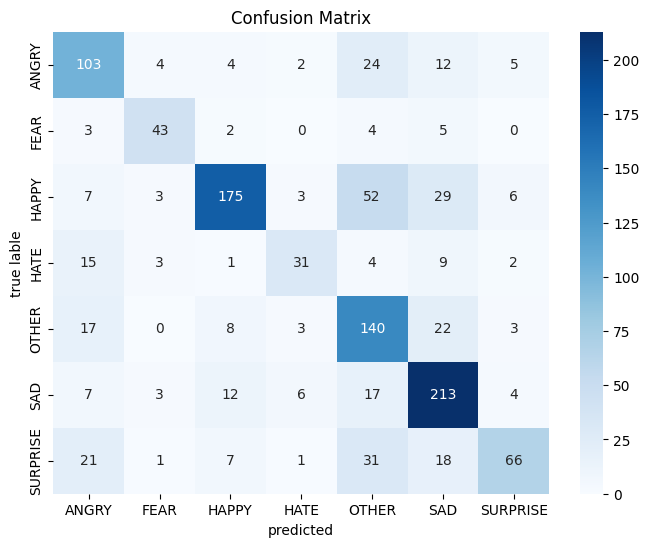

In [17]:
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

preds_output = trainer.predict(test_dataset)
y_true = preds_output.label_ids
y_pred = np.argmax(preds_output.predictions, axis=1)

print(classification_report(y_true, y_pred, target_names=class_names, zero_division=0))

cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names)
plt.xlabel('predicted')
plt.ylabel('true lable')
plt.title('Confusion Matrix')
plt.show()

In [18]:
import os
import json

SAVE_DIR = "/content/drive/MyDrive/final_project/models/text_emotion_parsbert"
os.makedirs(SAVE_DIR, exist_ok=True)

trainer.save_model(SAVE_DIR)
tokenizer.save_pretrained(SAVE_DIR)

label_map = {
    "label2id": {label: int(idx) for idx, label in enumerate(class_names)},
    "id2label": {int(idx): label for idx, label in enumerate(class_names)},
}
with open(os.path.join(SAVE_DIR, "label_map.json"), "w", encoding="utf-8") as f:
    json.dump(label_map, f, ensure_ascii=False, indent=2)

eval_summary = {
    "accuracy": test_results['eval_accuracy'],
    "macro_f1": test_results['eval_f1_macro'],
}
with open(os.path.join(SAVE_DIR, "eval_results.json"), "w", encoding="utf-8") as f:
    json.dump(eval_summary, f, ensure_ascii=False, indent=2)

print(f"model, tokenizer, label mapping and result are saved in:\n{SAVE_DIR}")

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

model, tokenizer, label mapping and result are saved in:
/content/drive/MyDrive/final_project/models/text_emotion_parsbert
